In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# We first get the dictionary of the hashes to augs
path = 'data/ssl_matrix.csv'
df = pd.read_csv(path, index_col=0)
# Iterate over the rows of the DataFrame
hash_to_aug = {}
for index, row in df.iterrows():
    augs = row['augs'].split('"')
    augs_list = [augs[1], augs[3]]
    hash_name = row['hashed_name']
    hash_to_aug[hash_name] = augs_list

In [3]:
path = 'data/matrix.csv'
df = pd.read_csv(path, index_col=0)

df['aug1'] = df['log_hash'].apply(lambda x: hash_to_aug[x][0])
df['aug2'] = df['log_hash'].apply(lambda x: hash_to_aug[x][1])
df = pd.concat([df, df.rename(columns={'aug1': 'aug2', 'aug2': 'aug1'})])

# rename 'Best Kappa (Fold 0)' to kappa
df.rename(columns={'Best Kappa (Fold 0)': 'kappa'}, inplace=True)
# Organise Kappa matrix
kappa_matrix_apple_watch = df[df['dataset_name'] == '["applewatch"]'][['kappa', 'aug1', 'aug2']].pivot(index='aug1', columns='aug2', values='kappa')
kappa_matrix_geneactiv = df[df['dataset_name'] == '["geneactiv"]'][['kappa', 'aug1', 'aug2']].pivot(index='aug1', columns='aug2', values='kappa')
kappa_matrix_newcastle = df[df['dataset_name'] == '["newcastle"]'][['kappa', 'aug1', 'aug2']].pivot(index='aug1', columns='aug2', values='kappa')

# Ensure the labels are in the same order for all matrices
common_labels = list(set(kappa_matrix_apple_watch.index).intersection(kappa_matrix_geneactiv.index).intersection(kappa_matrix_newcastle.index))
kappa_matrix_apple_watch = kappa_matrix_apple_watch.loc[common_labels, common_labels]
kappa_matrix_geneactiv = kappa_matrix_geneactiv.loc[common_labels, common_labels]
kappa_matrix_newcastle = kappa_matrix_newcastle.loc[common_labels, common_labels]

# We fill the NaN values on the diagonal with the mean of all numbers in the matrix
kappa_matrix_apple_watch.fillna(kappa_matrix_apple_watch.mean().mean(), inplace=True)
kappa_matrix_geneactiv.fillna(kappa_matrix_geneactiv.mean().mean(), inplace=True)
kappa_matrix_newcastle.fillna(kappa_matrix_newcastle.mean().mean(), inplace=True)


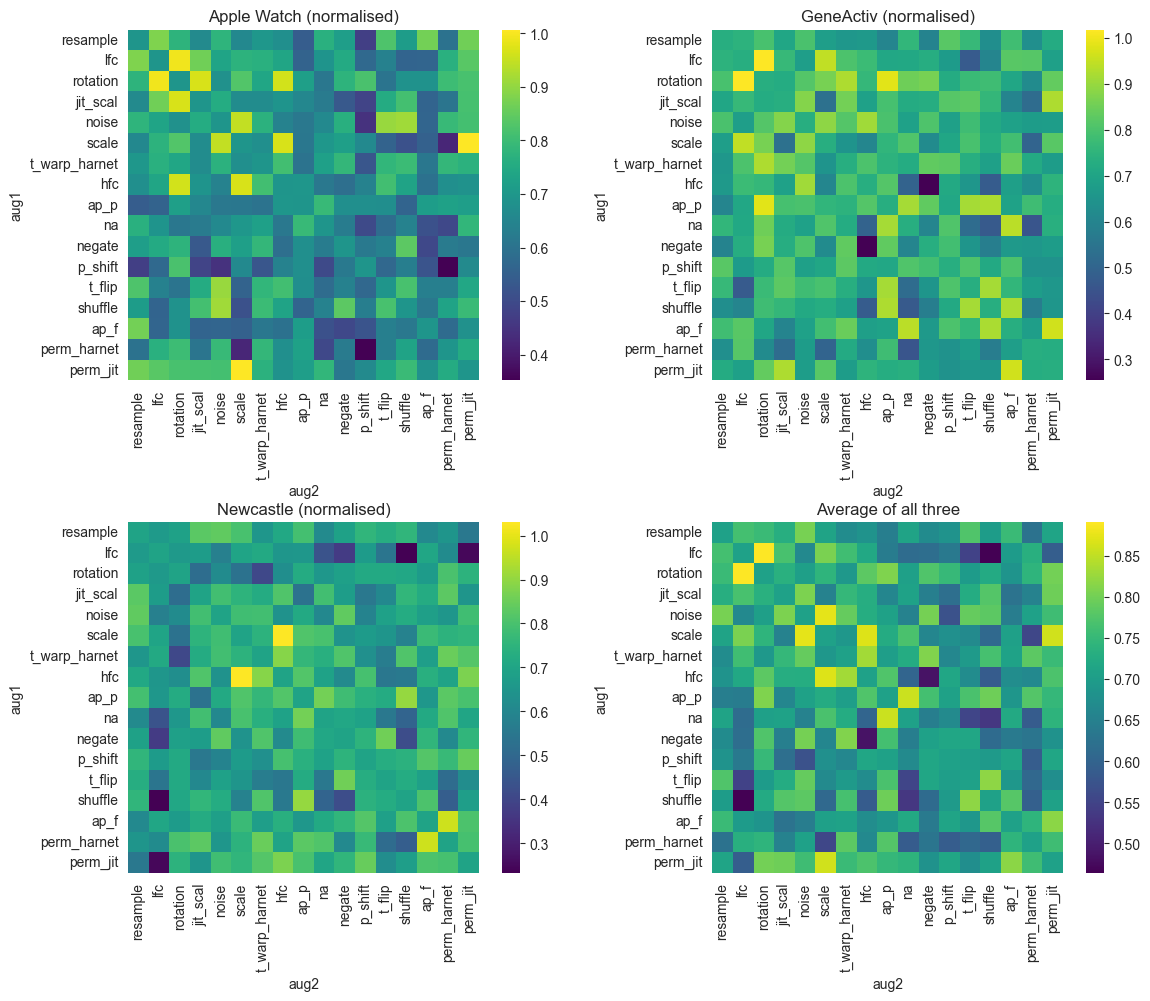

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from scipy.spatial import distance

# ---------------------------------------------------------------------------
# 1)  helper: robust clustering of κ-matrices
# ---------------------------------------------------------------------------
def cluster_kappa(
    kappa_df: pd.DataFrame,
    linkage_method: str = "complete",
    eps: float = 1e-12,
):
    """Return (re-ordered DataFrame, leaf_order) so that high-κ neighbours sit
    next to each other.  Raises if any κ > 1; clips round-off negatives."""
    if kappa_df.shape[0] != kappa_df.shape[1]:
        raise ValueError("Matrix must be square (same # rows and columns).")
    if not kappa_df.index.equals(kappa_df.columns):
        raise ValueError("Row and column labels must match & align.")

    dist = 1.0 - kappa_df.values
    if (dist < -eps).any():
        bad = kappa_df.values[dist < -eps][:5]
        raise ValueError(
            f"Found κ > 1 (e.g. {bad}); check how the matrix was built."
        )
    dist[dist < 0] = 0                           # clip tiny round-off noise
    np.fill_diagonal(dist, 0)

    Z   = sch.linkage(distance.squareform(dist), method=linkage_method)
    thr = dist.max() / 2.0                       # same rule-of-thumb as yours
    order = np.argsort(sch.fcluster(Z, thr, criterion="distance"))

    df_ord = kappa_df.iloc[order, :].iloc[:, order]
    return df_ord, order

# ---------------------------------------------------------------------------
# 2)  helper: normalise by mean of top-4 positives
# ---------------------------------------------------------------------------
def normalise_by_top4(df: pd.DataFrame) -> pd.DataFrame:
    vals = df.values.flatten()
    vals = vals[vals > 0]                        # ignore zeros
    mean_top4 = np.mean(np.sort(vals)[-4:])
    return df / mean_top4

# ---------------------------------------------------------------------------
# 3)  normalise the three source matrices
# ---------------------------------------------------------------------------
norm_apple     = normalise_by_top4(kappa_matrix_apple_watch)
norm_geneactiv = normalise_by_top4(kappa_matrix_geneactiv)
norm_newcastle = normalise_by_top4(kappa_matrix_newcastle)

# ---------------------------------------------------------------------------
# 4)  build the averaged matrix **(divide by 3, not 6)**
# ---------------------------------------------------------------------------
norm_mean = (norm_apple + norm_geneactiv + norm_newcastle) / 3

# ---------------------------------------------------------------------------
# 5)  cluster once on the mean & reuse the order everywhere
# ---------------------------------------------------------------------------
norm_mean_ord, leaf_order = cluster_kappa(norm_mean, linkage_method="complete")

# Re-index the individual matrices with the same order
norm_apple_ord     = norm_apple.iloc[leaf_order, :].iloc[:, leaf_order]
norm_geneactiv_ord = norm_geneactiv.iloc[leaf_order, :].iloc[:, leaf_order]
norm_newcastle_ord = norm_newcastle.iloc[leaf_order, :].iloc[:, leaf_order]

# ---------------------------------------------------------------------------
# 6)  quick faceted heat-map for visual inspection
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.heatmap(norm_apple_ord,     ax=axes[0, 0], cmap="viridis", square=True)
axes[0, 0].set_title("Apple Watch (normalised)")

sns.heatmap(norm_geneactiv_ord, ax=axes[0, 1], cmap="viridis", square=True)
axes[0, 1].set_title("GeneActiv (normalised)")

sns.heatmap(norm_newcastle_ord, ax=axes[1, 0], cmap="viridis", square=True)
axes[1, 0].set_title("Newcastle (normalised)")

sns.heatmap(norm_mean_ord,      ax=axes[1, 1], cmap="viridis", square=True)
axes[1, 1].set_title("Average of all three")

plt.tight_layout()



plt.show()